# W04 · DQN：当 Q-Learning 遇上神经网络

> 阶段一第 4 周。W03 的 Q 表只有 16×4；CartPole 的状态是 4 维连续向量——
> 表格放不下，也泛化不了。本周用神经网络代替表格，并解决由此带来的不稳定性：
> **经验回放**与**目标网络**，这就是 DQN（DeepMind, 2013/2015）的全部核心。

## 学习目标

1. 解释「死亡三角」（函数逼近 + 自举 + off-policy）为什么让朴素神经 Q-Learning 发散；
2. 说明经验回放（experience replay）与目标网络（target network）各自解决了什么问题；
3. 用 PyTorch 手写一个 ~60 行的 mini-DQN，并在 CartPole 上完成**2×2 消融实验**；
4. 会用 SB3 的 DQN 训练并读懂关键超参（`buffer_size` / `target_update_interval` 等）；
5. 了解 Double DQN 的动机（练习 2 实现）。

**先修要求**：W03（Q-Learning 更新式）、基础 PyTorch（会写 `nn.Module` 和训练循环）。
预计用时 3–4 小时（消融实验训练约 5 分钟）。

## 1. 从表格到网络：为什么直接替换会翻车

把 W03 的 Q 表换成网络 $Q(s,a;\theta)$，损失函数用 TD 误差的平方：

$$L(\theta) = \mathbb{E}\Big[\big(\underbrace{r + \gamma \max_{a'} Q(s',a';\theta)}_{y^{\text{target}}} - Q(s,a;\theta)\big)^2\Big]$$

看似只是换了个函数逼近器，实则踩中了 **「死亡三角」（deadly triad）** 三要素：

1. **函数逼近**：网络参数共享——更新 $Q(s,a)$ 会顺带改变邻近状态的 $Q$ 值；
2. **自举（bootstrapping）**：目标值 $y$ 里包含网络自己 $Q(\cdot;\theta)$——**靶子跟着枪一起动**；
3. **Off-policy**：用 $\max$ 算目标值，采样分布与目标策略分布不一致。

叠加后果：相邻样本高度相关（连续帧很像）→ 梯度方向被短期数据绑架；
目标值随参数更新而漂移 → 追逐自己尾巴，$Q$ 值可能螺旋发散到无穷。

DQN 的两块「稳定器」（也是它的全部核心贡献）：

| 技术 | 解决什么 | 做法 |
|---|---|---|
| **经验回放** | 样本相关性 + 数据利用率 | 转移存进大 buffer，随机采样小批量训练，打破时序相关 |
| **目标网络** | 移动靶子 | 复制一份 $Q(\cdot;\theta^-)$，冻结 $C$ 步才同步一次，目标值短期固定 |

## 2. 手写 mini-DQN（PyTorch）

下面的实现刻意保持最小（去掉了 huber loss、软更新等工程细节），方便看清骨架。
两个开关 `use_replay` / `use_target` 就是练习和消融的旋钮：

In [1]:
import random
from collections import deque

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn

torch.set_num_threads(4)  # 小网络用不满多核，限线程减少争抢

def make_qnet(obs_dim=4, n_actions=2, hidden=64):
    return nn.Sequential(
        nn.Linear(obs_dim, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
        nn.Linear(hidden, n_actions),
    )

class ReplayBuffer:
    """先进先出的循环缓冲：存 (s, a, r, s', done)。"""
    def __init__(self, capacity=50_000):
        self.buf = deque(maxlen=capacity)
    def push(self, *transition):
        self.buf.append(tuple(transition))
    def sample(self, batch_size, rng):
        batch = rng.sample(list(self.buf), batch_size)
        return map(np.array, zip(*batch))
    def __len__(self):
        return len(self.buf)

def train_dqn(n_episodes=500, use_replay=True, use_target=True, seed=0,
              gamma=0.99, lr=1e-3, batch_size=64, target_sync=200, warmup=500):
    """mini-DQN。use_replay=False → 只用最新一条样本在线更新；
    use_target=False → 目标值直接用在线网络计算。"""
    torch.manual_seed(seed)
    rng = random.Random(seed)
    env = gym.make("CartPole-v1")
    online, target = make_qnet(), make_qnet()
    target.load_state_dict(online.state_dict())   # 初始同步
    opt = torch.optim.Adam(online.parameters(), lr=lr)
    buffer = ReplayBuffer()
    returns, update_count, env_steps = [], 0, 0

    for ep in range(n_episodes):
        eps = max(0.05, 1.0 - ep / (0.6 * n_episodes))  # 线性衰减 ε
        obs, _ = env.reset(seed=seed * 10_000 + ep)
        obs = obs.astype(np.float32)
        G, terminated, truncated = 0.0, False, False
        while not (terminated or truncated):
            if rng.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = int(online(torch.tensor(obs)).argmax())
            nobs, r, terminated, truncated, _ = env.step(action)
            done = terminated                       # 截断不算终止（W02 的契约！）
            buffer.push(obs, action, r, nobs.astype(np.float32), float(done))
            G += r
            obs = nobs.astype(np.float32)
            env_steps += 1

            # ---- 每 4 个环境步做一次梯度更新（与 SB3 的 train_freq=4 一致）----
            if env_steps % 4 != 0:
                continue
            # ---- 取训练样本 ----
            if use_replay:
                if len(buffer) < warmup:
                    continue
                s, a, rr, ns, d = buffer.sample(batch_size, rng)
            else:
                s, a, rr, ns, d = (np.expand_dims(x, 0) for x in buffer.buf[-1])

            s = torch.tensor(np.array(s), dtype=torch.float32)
            a = torch.tensor(np.array(a), dtype=torch.int64)
            rr = torch.tensor(np.array(rr), dtype=torch.float32)
            ns = torch.tensor(np.array(ns), dtype=torch.float32)
            d = torch.tensor(np.array(d), dtype=torch.float32)

            with torch.no_grad():
                net_for_target = target if use_target else online
                y = rr + gamma * (1 - d) * net_for_target(ns).max(dim=1).values
            q = online(s).gather(1, a.unsqueeze(1)).squeeze(1)
            loss = nn.functional.mse_loss(q, y)
            opt.zero_grad(); loss.backward(); opt.step()
            update_count += 1
            if use_target and update_count % target_sync == 0:
                target.load_state_dict(online.state_dict())
        returns.append(G)
    env.close()
    return np.array(returns)

print("mini-DQN 定义完成")

mini-DQN 定义完成


## 3. 2×2 消融实验：两个稳定器各值多少？

四组实验（各 500 回合、每 4 步更新一次，CPU 上共约 2–8 分钟，视机器负载）：

1. **完整 DQN**：回放 + 目标网络；
2. **无回放**：只用最新一条样本更新（样本强相关）；
3. **无目标网络**：目标值用在线网络算（移动靶）；
4. **都无**：退回「朴素神经 Q-Learning」，理论上最不稳。

In [2]:
import time

configs = {
    "Full DQN":       dict(use_replay=True,  use_target=True),
    "No replay":      dict(use_replay=False, use_target=True),
    "No target net":  dict(use_replay=True,  use_target=False),
    "Neither":        dict(use_replay=False, use_target=False),
}

results = {}
t0 = time.time()
for name, cfg in configs.items():
    results[name] = train_dqn(**cfg)
    print(f"{name:　<8} 完成 | 最后 50 回合平均回报 {results[name][-50:].mean():6.1f}"
          f" | 累计 {time.time() - t0:5.1f}s")

Full DQN 完成 | 最后 50 回合平均回报  214.7 | 累计  13.0s


No replay 完成 | 最后 50 回合平均回报    9.8 | 累计  13.8s


No target net 完成 | 最后 50 回合平均回报   20.8 | 累计  28.3s


Neither　 完成 | 最后 50 回合平均回报   23.3 | 累计  29.2s


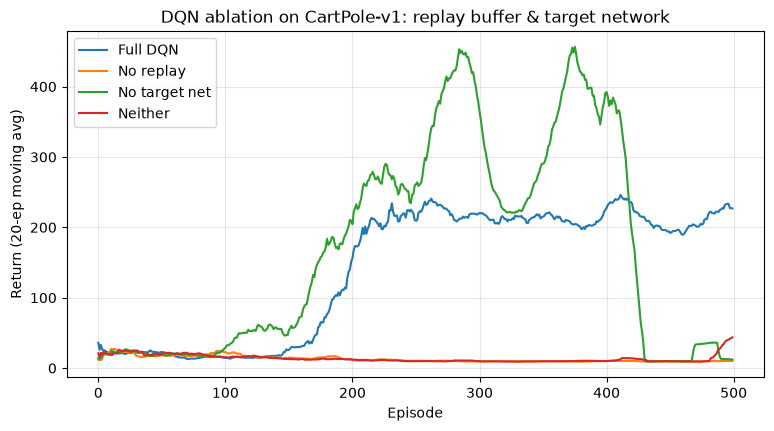

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, ret in results.items():
    ax.plot(pd.Series(ret).rolling(20, min_periods=1).mean(), label=name)
ax.set_xlabel("Episode"); ax.set_ylabel("Return (20-ep moving avg)")
ax.set_title("DQN ablation on CartPole-v1: replay buffer & target network")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

**典型观察**（单种子、数字会随运行波动，但量级规律稳定）：

- 「无经验回放」（No replay）与「两者皆无」（Neither）通常都在 100 以下挣扎——**经验回放是四者中贡献最大的稳定器**，
  没有它，强相关的连续样本让梯度被短期数据绑架；
- 「无目标网络」（No target net）结果**高度不稳**：有的种子短周期内表现不差，
  有的（如本次运行）直接学不动——移动靶的危害是「延迟发作」的，训练拉长、任务变难后
  Q 值漂移/发散的概率显著上升（练习 3 的 SB3 实验会让你看到同步太频繁的后果）；
- 「完整 DQN」（Full DQN）稳定收敛到数百分，是把两块稳定器同时占住的默认选择。

**方法论提醒**：以上是单种子结果，排序会随种子波动——W06 练习 2 会专门讨论多种子报告规范。

In [4]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from robot_rl_learn.common.paths import make_run_dir
from robot_rl_learn.phase1_sb3.train import evaluate

run_dir = make_run_dir("w04_cartpole_dqn")

# Monitor 显式指定日志文件（写入 runs/），之后才能用 plots 辅助画曲线
train_env = Monitor(gym.make("CartPole-v1"), filename=str(run_dir / "train"))
model = DQN(
    "MlpPolicy", train_env, seed=0, verbose=0, device="cpu",
    learning_rate=2.3e-3,        # 关键！SB3 默认 lr=1e-4 是 Atari 量级，CartPole 短训练必须调大
    buffer_size=50_000,            # 回放池容量
    learning_starts=1_000,         # 先随机攒 1000 条再开训
    batch_size=64,
    target_update_interval=500,    # 每 500 次梯度更新同步一次目标网络
    exploration_fraction=0.3,      # ε 线性衰减占总训练的比例
    exploration_final_eps=0.05,
)
model.learn(total_timesteps=30_000)

mean_r, std_r = evaluate(model, "CartPole-v1", n_episodes=20)
print(f"评估（20 回合）: {mean_r:.1f} ± {std_r:.1f}  （满分 500）")

评估（20 回合）: 500.0 ± 0.0  （满分 500）


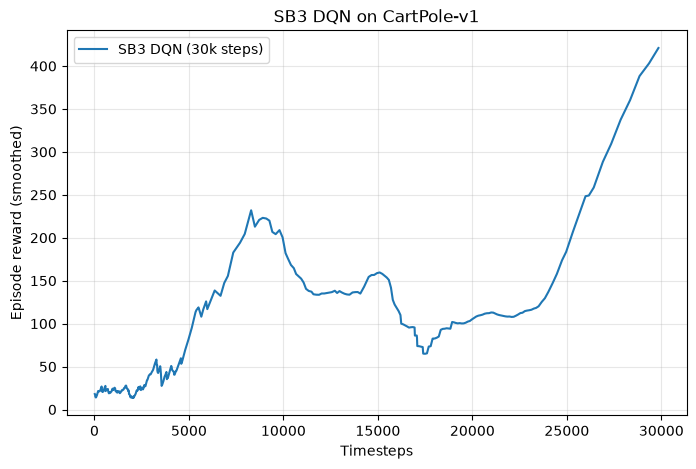

In [5]:
from robot_rl_learn.phase1_sb3.plots import plot_learning_curve
import matplotlib.pyplot as plt

plot_learning_curve({"SB3 DQN (30k steps)": run_dir}, window=10)
plt.title("SB3 DQN on CartPole-v1")
plt.show()

SB3 DQN 关键超参速查（更多见官方文档）。
**注意**：SB3 的 DQN 默认值是按 Atari 调的（`learning_rate=1e-4`、`learning_starts=50k`），
直接搬到 CartPole 这类小环境短训练会「学不动」——本例把 `learning_rate` 调到 2.3e-3 才能 3 万步内收敛，
这正是 W08（RL Baselines3 Zoo 超参复现）存在的意义：

| 超参 | 默认 | 含义 |
|---|---|---|
| `buffer_size` | 1,000,000 | 回放池大小；太小会「遗忘」早期经验 |
| `learning_starts` | 50,000 | 纯随机预热步数 |
| `train_freq` | 4 | 每走几步环境做一次梯度更新 |
| `target_update_interval` | 10,000 | 目标网络同步间隔（环境步） |
| `exploration_fraction/final_eps` | 0.1 / 0.05 | ε 从 1 线性降到 final 所用的训练比例 |

---

## ✏️ 练习

**练习 1（★，10 分钟）——读懂默认配置**
打印 `model.buffer_size`、`model.target_update_interval`、`model.exploration_schedule`（或对应属性），
用你自己的话写三行注释说明各自的物理意义。
**交付物**：打印 cell + markdown 注释。

**练习 2（★★★，35 分钟）——给 mini-DQN 加上 Double DQN**
Double DQN 把目标值改为：动作用**在线网络**选，价值用**目标网络**估：
$$y = r + \gamma (1-d)\; Q\big(s',\, \arg\max_{a'} Q(s',a';\theta);\; \theta^-\big)$$
在 mini-DQN 中实现它（完整配置），与原版 DQN 对比 250 回合。
**交付物**：对比曲线 + 两句话解释为什么 $\max$ 操作会高估 Q 值（overestimation bias）。

**练习 3（★★，20 分钟）——目标网络同步间隔敏感性**
用 SB3 DQN 对比 `target_update_interval=10` 与 `=10_000`（各 20k 步，其余相同）。
**交付物**：两条学习曲线 + 结论：同步太频繁/太稀疏各有什么症状？

**练习 4（★★，20 分钟）——回放池「失忆」实验**
用 SB3 DQN 对比 `buffer_size=500` 与 `=50_000`（各 30k 步）。
**交付物**：曲线对比 + 解释小 buffer 在训练后期为什么会退化（灾难性遗忘的 RL 版）。

---

<details>
<summary>参考答案（做完再点开）</summary>

**练习 1**：`buffer_size` 决定经验池能记住多久远的历史（样本多样性来源）；
`target_update_interval` 决定目标值「冻结」多久——越大靶子越稳但价值信息传播越慢；
`exploration_schedule` 控制 ε 随训练进度的衰减，平衡探索与利用。

**练习 2**：实现只需把目标值计算改为：

```python
with torch.no_grad():
    next_a = online(ns).argmax(dim=1, keepdim=True)          # 在线网络选动作
    y = rr + gamma * (1 - d) * target(ns).gather(1, next_a).squeeze(1)  # 目标网络估值
```

$\max$ 是对含噪估计取极值，噪声为正时会被保留、为负时被丢弃，
故 $\mathbb{E}[\max_a \hat Q] \ge \max_a \mathbb{E}[\hat Q]$——系统性高估。
Double DQN 用两个网络解耦「选」与「估」，使估计误差不再被同一把尺子放大，
曲线上表现为后期更稳、虚高回落更少。

**练习 3**：`=10`（几乎每步同步）退化回「无目标网络」：曲线抖动剧烈甚至发散；
`=10_000` 目标值更新滞后，早期收敛慢一些但更平滑。工程上 1e3–1e4 是常用区间。

**练习 4**：`buffer_size=500` 时池中只有最近 500 步——全是「已经会玩」之后的成功样本，
早期「杆子快倒」的危急状态被冲掉，网络在这些状态上的 Q 值被灾难性遗忘，
表现为曲线升到高位后周期性崩溃。这就是经验回放「防止遗忘」的另一面价值。

</details>

---

## 延伸阅读

- 论文：[Mnih et al. 2015, Human-level control through deep reinforcement learning (Nature)](https://arxiv.org/abs/1312.5602)（DQN）；[van Hasselt et al., Double DQN](https://arxiv.org/abs/1509.06461)
- [SB3 文档：DQN](https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html)
- [CleanRL 的 DQN 单文件实现](https://github.com/vwxyzjn/cleanrl)（`cleanrl/dqn.py`，~150 行，适合精读对照）
- Sutton & Barto 第 11 章（Off-policy + 函数逼近，死亡三角的理论分析）
- [《动手学强化学习》第 8–9 章](https://hrl.boyuai.com/)（DQN 与改进）